In [1]:
pip install transformers torch 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

In [3]:
df = pd.read_csv("../sentiment analysis.csv")

df.head()

,Complaint ID,Category,Sub Category,Grievance Date,Ward Name,Grievance Status,Staff Remarks,Staff Name
0,20771690,Electrical,Street Light Not Working,2025-06-19 10:39:00.000000000,Jagajeevanram Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE
1,20771689,Electrical,Street Light Not Working,2025-06-19 10:36:00.000000000,Kammanahalli,Registered,1st Assignment Based on Ward Mapping,Vinay Kumar/AE
2,20771688,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:35:00.000000000,Banaswadi,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 27/Marshal
3,20771687,Electrical,Street Light Not Working,2025-06-19 10:34:00.000000000,Gandhi Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE
4,20771686,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:34:00.000000000,Kumaraswamy Layout,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 181/Marshal


In [4]:
df.shape

df.columns

df.info()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 126974 entries, 0 to 126973
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Complaint ID      126974 non-null  int64
 1   Category          126974 non-null  str  
 2   Sub Category      126974 non-null  str  
 3   Grievance Date    126974 non-null  str  
 4   Ward Name         126974 non-null  str  
 5   Grievance Status  126920 non-null  str  
 6   Staff Remarks     126920 non-null  str  
 7   Staff Name        126920 non-null  str  
dtypes: int64(1), str(7)
memory usage: 7.8 MB


Complaint ID         0
Category             0
Sub Category         0
Grievance Date       0
Ward Name            0
Grievance Status    54
Staff Remarks       54
Staff Name          54
dtype: int64

In [5]:
df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

df.shape

(126920, 8)

In [6]:
import re

def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'http\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

In [7]:
df['clean_text'] = df['Sub Category'].apply(clean_text)

df[['Sub Category','clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light not working
1,Street Light Not Working,street light not working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light not working
4,Garbage dump,garbage dump


In [8]:
import nltk

nltk.download('punkt')

nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Global\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Global\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
import re

def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'http\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

df['clean_text'] = df['Sub Category'].apply(clean_text)

df[['Sub Category', 'clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light not working
1,Street Light Not Working,street light not working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light not working
4,Garbage dump,garbage dump


In [10]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    
    words = word_tokenize(text)
    
    filtered = [word for word in words if word not in stop_words]
    
    return " ".join(filtered)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

df[['Sub Category','clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light working
1,Street Light Not Working,street light working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light working
4,Garbage dump,garbage dump


In [11]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Global\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [12]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    
    words = text.split()
    
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

df['clean_text'] = df['clean_text'].apply(lemmatize_text)

df[['Sub Category','clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light working
1,Street Light Not Working,street light working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light working
4,Garbage dump,garbage dump


In [13]:
df['clean_text'].head()

0    street light working
1    street light working
2            garbage dump
3    street light working
4            garbage dump
Name: clean_text, dtype: str

In [14]:
df.to_csv("cleaned_grievance_data.csv",index=False)

In [15]:
df.head()

,Complaint ID,Category,Sub Category,Grievance Date,Ward Name,Grievance Status,Staff Remarks,Staff Name,clean_text
0,20771690,Electrical,Street Light Not Working,2025-06-19 10:39:00.000000000,Jagajeevanram Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE,street light working
1,20771689,Electrical,Street Light Not Working,2025-06-19 10:36:00.000000000,Kammanahalli,Registered,1st Assignment Based on Ward Mapping,Vinay Kumar/AE,street light working
2,20771688,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:35:00.000000000,Banaswadi,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 27/Marshal,garbage dump
3,20771687,Electrical,Street Light Not Working,2025-06-19 10:34:00.000000000,Gandhi Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE,street light working
4,20771686,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:34:00.000000000,Kumaraswamy Layout,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 181/Marshal,garbage dump


In [16]:
classifier = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [17]:
sample_text = "Garbage is overflowing near the road"

result = classifier(sample_text)

print(result)

[{'label': 'NEGATIVE', 'score': 0.999545156955719}]


In [21]:
df['bert_sentiment'] = df['clean_text'].apply(
    lambda x: classifier(str(x))[0]['label']
)
df[['clean_text','bert_sentiment']].head()               

,clean_text,bert_sentiment
0,street light working,POSITIVE
1,street light working,POSITIVE
2,garbage dump,NEGATIVE
3,street light working,POSITIVE
4,garbage dump,NEGATIVE


In [ ]:
print(df.columns) 

Index(['Complaint ID', 'Category', 'Sub Category', 'Grievance Date',
       'Ward Name', 'Grievance Status', 'Staff Remarks', 'Staff Name',
       'clean_text', 'bert_sentiment'],
      dtype='str')


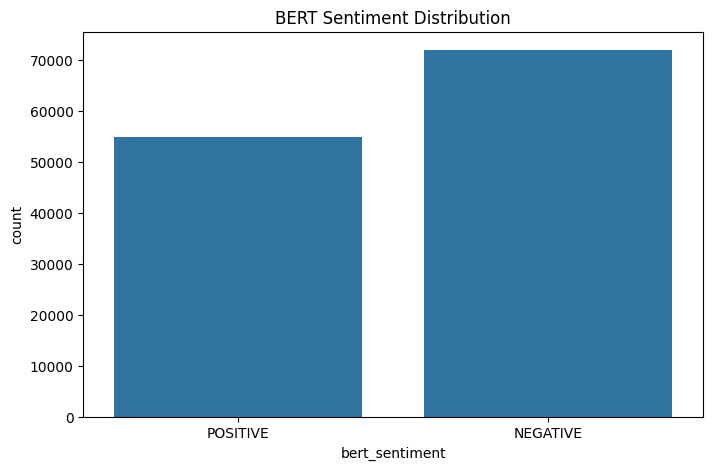

In [22]:
plt.figure(figsize=(8,5))    

sns.countplot(x=df['bert_sentiment'])

plt.title("BERT Sentiment Distribution")

plt.show()

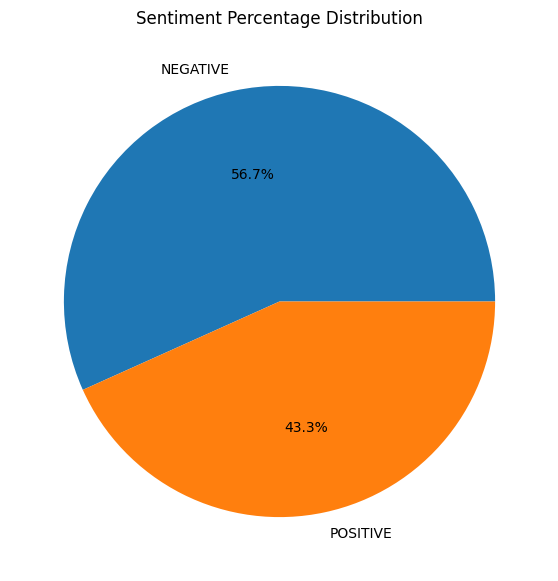

In [23]:
df['bert_sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Sentiment Percentage Distribution")

plt.ylabel("")

plt.show()

In [24]:
def urgency_score(sentiment):

    if sentiment == "NEGATIVE":
        return 4

    elif sentiment == "POSITIVE":
        return 1

    else:
        return 2

In [25]:
df['priority_score'] = df['bert_sentiment'].apply(
    urgency_score
)

df[['bert_sentiment', 'priority_score']].head()

,bert_sentiment,priority_score
0,POSITIVE,1
1,POSITIVE,1
2,NEGATIVE,4
3,POSITIVE,1
4,NEGATIVE,4


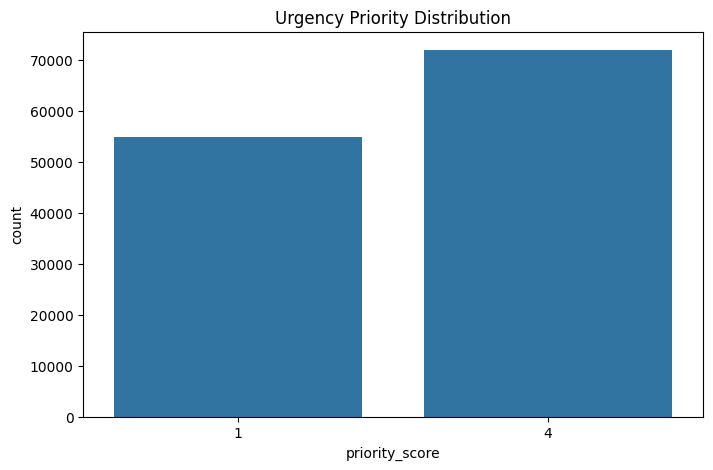

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['priority_score'])

plt.title("Urgency Priority Distribution")

plt.show()

In [27]:
user_input = input("Enter Citizen Complaint : ")

prediction = classifier(user_input)

sentiment = prediction[0]['label']

priority = urgency_score(sentiment)

print("\nPredicted Sentiment :", sentiment)

print("Priority Score :", priority)


Predicted Sentiment : NEGATIVE
Priority Score : 4


# Week 4 


In [28]:
df.to_csv("cleaned_grievance_data.csv",index=False)

In [29]:
X = df['clean_text']

y = df['Category']

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_vectorized = vectorizer.fit_transform(X)

In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_vectorized, y)

print("Model Ready")

Model Ready


In [32]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_vectorized)

print(classification_report(y, y_pred))

c:\Users\Global\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Global\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                               precision    recall  f1-score   support

                Advertisement       1.00      1.00      1.00       699
         BBMP Election Branch       0.00      0.00      0.00         7
               CORONA COVID19       0.00      0.00      0.00        18
                  Call Center       1.00      0.49      0.65        72
     E khata / Khata services       1.00      1.00      1.00      4189
                    Education       0.00      0.00      0.00        14
                   Electrical       1.00      1.00      1.00     42134
                       Estate       0.00      0.00      0.00        60
                       Forest       1.00      1.00      1.00      6320
                  Health Dept       0.99      1.00      1.00      3372
               Indira Canteen       1.00      0.80      0.89       173
       Information Technology       1.00      1.00      1.00        66
                        Lakes       1.00      1.00      1.00       318
     

c:\Users\Global\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


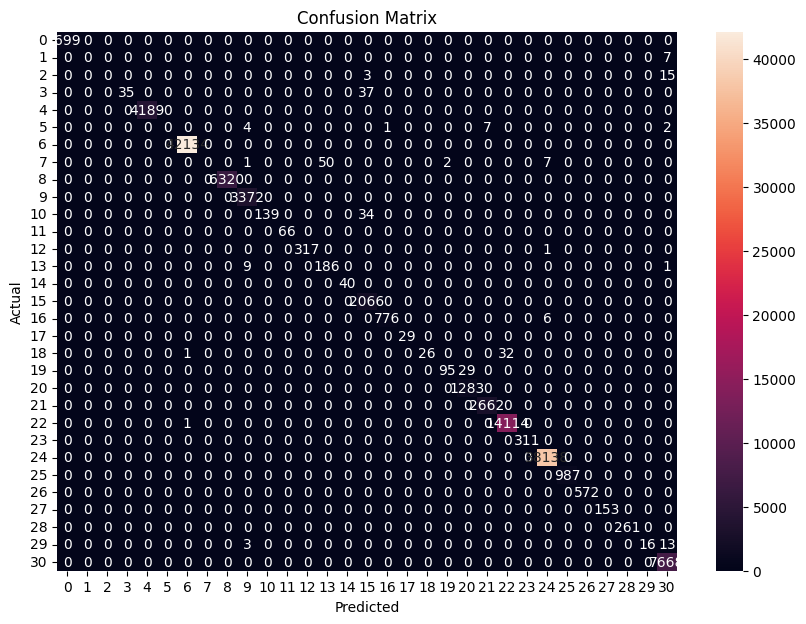

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [34]:
import joblib

joblib.dump(model, "department_model.pkl")

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Models Saved Successfully")

Models Saved Successfully


In [35]:
pip install fastapi uvicorn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
